In [1]:
import os
os.chdir("../")
from src.adecuacion import corrector, ImagenHyper
from src.spacial_bin import binning
from src.labeling import identificar_muestras1, enseñar_muestras,y_prop_label_generation, y_prop_label_generation, combinar_labels, espectros_muestras
from src.rgb import img_rgb, imagen_prediccion
import matplotlib.pyplot as plt
import numpy as np
ruta1="""E:/TFM IMAGENES/IMAGENES/"""
dia='30ene2026/'
nombre_muestra='30ene2026_0001_arenas'
ruta2='/capture/'
white='WHITEREF_'
dark='DARKREF_'
extension='.hdr'

"D:\TFM IMAGENES\IMAGENES\30ene2026\30ene2026_0001_arenas\capture\WHITEREF_30ene2026_0001_arenas.hdr"
ruta_imagen=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/{nombre_muestra}{extension}"
ruta_blanco=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/WHITEREF_{nombre_muestra}{extension}"
ruta_negro=f"E:/TFM IMAGENES/IMAGENES/{dia}/{nombre_muestra}/capture/DARKREF_{nombre_muestra}{extension}"
imagen_arena =corrector(ruta_imagen=ruta_imagen,ruta_blanco=ruta_blanco,ruta_negro=ruta_negro)

<>:17: SyntaxWarning: invalid escape sequence '\T'
<>:17: SyntaxWarning: invalid escape sequence '\T'
C:\Users\unaif\AppData\Local\Temp\ipykernel_13148\3417056935.py:17: SyntaxWarning: invalid escape sequence '\T'
  "D:\TFM IMAGENES\IMAGENES\30ene2026\30ene2026_0001_arenas\capture\WHITEREF_30ene2026_0001_arenas.hdr"
c:\Users\unaif\anaconda3\envs\TFM\Lib\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


In [2]:
imagen_arena=ImagenHyper(imagen_arena[0],imagen_arena[1] )

In [3]:
arena_binned=binning(imagen_arena,2)

In [4]:
from sklearn.cluster import KMeans

from src.adecuacion import img2matrix, matrix2img, ImagenHyper, replace_from_coords

n_clusters = 4
kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)
h, w, b = arena_binned.shape
labels = kmeans.fit_predict(arena_binned.spectra)

cluster_map=matrix2img(labels,h=h, w=w, b=1)

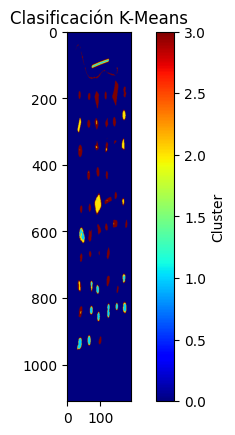

In [5]:

plt.imshow(cluster_map, cmap="jet")
plt.colorbar(label="Cluster")
plt.title("Clasificación K-Means")
plt.show()

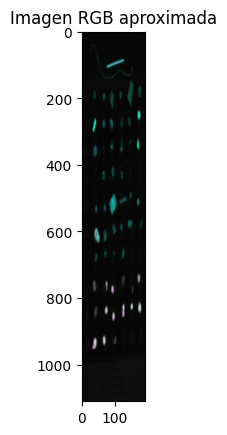

In [6]:
mask = np.argwhere(cluster_map == 0)[:,0:2]
img_rgb(replace_from_coords(arena_binned.img, cluster_map,0))

In [7]:
mask=replace_from_coords(arena_binned.img, mask, 0).astype(bool)[:,:,0]

In [8]:
arena_binned.add_mask(mask=mask)

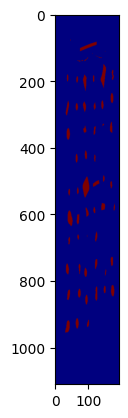

In [9]:
from skimage.morphology import erosion, disk
import matplotlib.pyplot as plt
mask_eroded = erosion(arena_binned.mask, disk(1) )

plt.Figure(figsize=(15,15))
plt.imshow(mask_eroded, cmap="jet")

In [10]:
arena_binned.add_mask(mask_eroded)

In [11]:
arena_binned_sliced=arena_binned.slicer("auto")

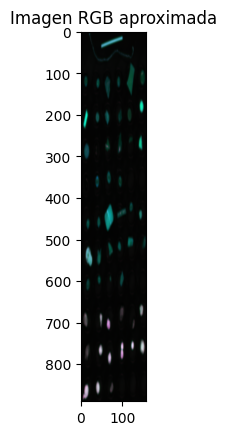

In [12]:
img_rgb(arena_binned_sliced.img)

In [13]:
n_plasticos, props=identificar_muestras1(arena_binned_sliced)

Plásticos detectados: 59


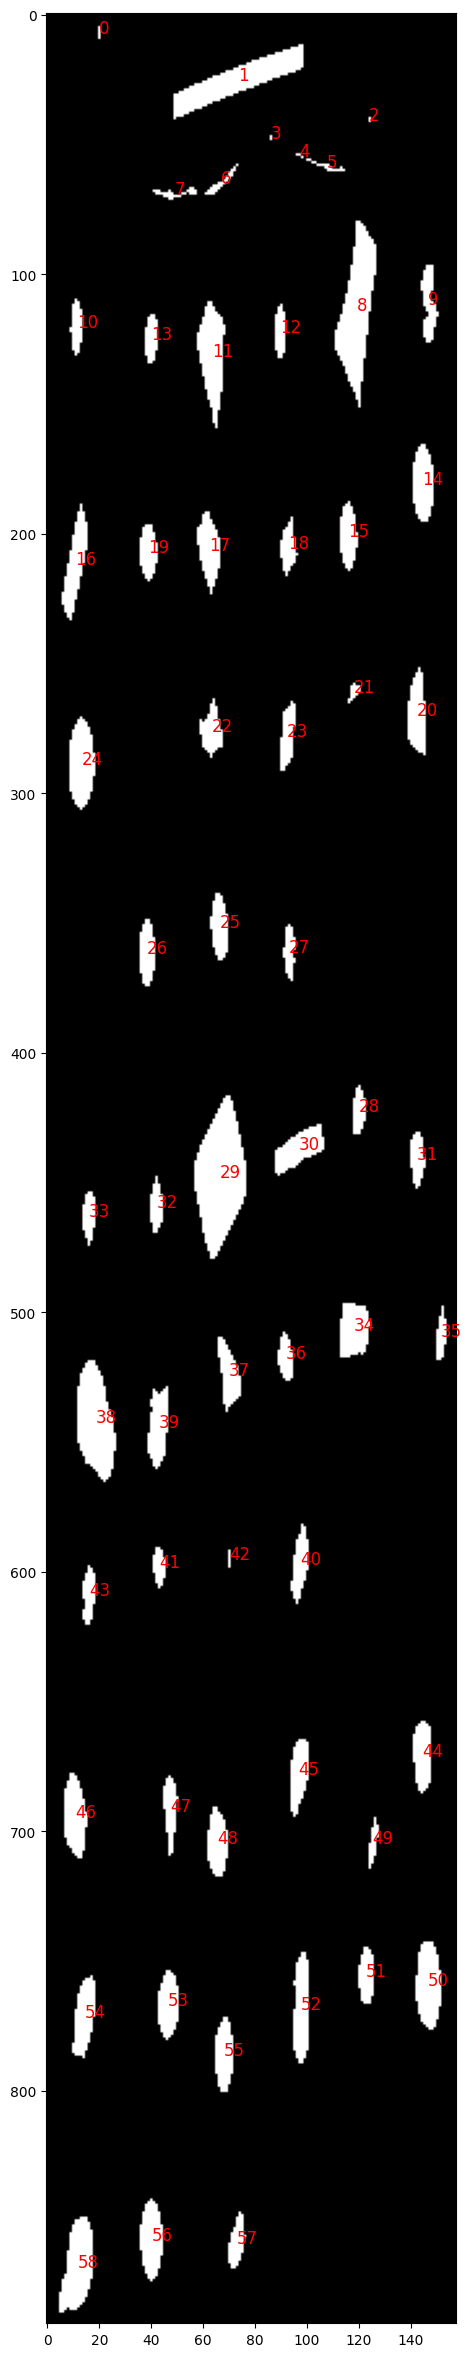

In [14]:
enseñar_muestras(arena_binned_sliced.mask, props=props)

In [15]:
---

SyntaxError: invalid syntax (1947214667.py, line 1)

In [16]:
y_prop_label=y_prop_label_generation(59)
y_prop_label[0]=1
y_prop_label[1]=2
y_prop_label[2:28]=1
y_prop_label[28:42]=2
y_prop_label[42]=1
y_prop_label[43]=2
y_prop_label[44:59]=3
y_prop_label

array([1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

In [17]:
combinar_labels(arena_binned_sliced,y_prop_label, props)

In [18]:
os.getcwd()

'c:\\Users\\unaif\\TFM PYTHON\\Repositorio\\TFM'

In [19]:
import pickle
with open("DATA/arena_binned_sliced.pkl", "wb") as f:
    pickle.dump(arena_binned_sliced, f)

True